In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
K = 12
gamma = 0.95

START = (0, 0)
GOAL = (K-1, K-1)

ACTIONS = {
    0: (-1, 0),  # North
    1: (1, 0),   # South
    2: (0, 1),   # East
    3: (0, -1),  # West
}

def is_valid(state): #Actions that go out of bounds are forbidden (0.k)
    x, y = state
    return 0 <= x < K and 0 <= y < K

def step(state, action):
    if state == GOAL: # If you are already at the goal:you stay there forever
        return state, 0

    dx, dy = ACTIONS[action] #Computing next state . where system wants to go
    next_state = (state[0] + dx, state[1] + dy)

    if not is_valid(next_state):
        next_state = state  # if try to leave the grid → stay but still gets punished -1

    if next_state == GOAL: #if next step is reaching the goal
        reward = 2 * (K - 1)
    else:
        reward = -1

    return next_state, reward


In [ ]:
# Random policy: one random action per state
policy = np.random.randint(0, len(ACTIONS), size=(K, K))

# Value function J^π =0
V = np.zeros((K, K))

# Terminal state handling
policy[GOAL] = 0   # arbitrary, never used
V[GOAL] = 0.0


In [ ]:
#policy iteration:

theta = 1e-4  # stopping threshold
policy_stable = False #in start no better action avaiable

while not policy_stable:

# POLICY EVALUATION

    while True: #Loop until Δ < θ
        delta = 0

        for x in range(K): # ∀s∈S - We update every state in the grid.
            for y in range(K):
                state = (x, y)

                if state == GOAL:
                    continue

                v = V[x, y] # Store old value
                action = policy[x, y]  # The policy tells us which action to evaluate.

                next_state, reward = step(state, action) #Next state s' and Immediate reward . P(s′∣s,a)=1
                nx, ny = next_state

                V[x, y] = reward + gamma * V[nx, ny] # bellmans equation: Jπ(s)=r+γJπ(s′)

                delta = max(delta, abs(v - V[x, y])) # Update Δ

        if delta < theta: # UNTIL Δ < θ
            break

  # 3. POLICY IMPROVEMENT
    policy_stable = True

    for x in range(K): #∀s∈S
        for y in range(K):
            state = (x, y)

            if state == GOAL: #skip
                continue

            old_action = policy[x, y]

            action_values = []

            for a in ACTIONS: #∀a∈A(s)
                next_state, reward = step(state, a) #again: s′∑​P(s′∣s,a)[r+γJπ(s′)]
                nx, ny = next_state
                action_values.append(reward + gamma * V[nx, ny])

            best_action = np.argmax(action_values) # π(s)=argamax​Q(s,a) greedy policy improvement step.
            policy[x, y] = best_action

            if old_action != best_action:
                policy_stable = False

V_pi = V.copy() #value function from policy iteration
policy_pi = policy.copy() #optimal policy from policy iteration


In [ ]:
# VALUE ITERATION

V = np.zeros((K, K))
theta = 1e-4

while True:
    delta = 0

    for x in range(K):
        for y in range(K):
            state = (x, y)

            if state == GOAL:
                continue

            v = V[x, y]

            action_values = []

            for a in ACTIONS:
                next_state, reward = step(state, a)
                nx, ny = next_state
                action_values.append(reward + gamma * V[nx, ny])

            V[x, y] = max(action_values)

            delta = max(delta, abs(v - V[x, y]))

    if delta < theta:
        break

V_vi = V
policy_vi = policy


In [ ]:
# OPTIMAL POLICY EXTRACTION

policy = np.zeros((K, K), dtype=int)

for x in range(K):
    for y in range(K):
        state = (x, y)

        if state == GOAL:
            continue

        action_values = []

        for a in ACTIONS:
            next_state, reward = step(state, a)
            nx, ny = next_state
            action_values.append(reward + gamma * V[nx, ny])
#We choose the action that maximizes the expected return according to the optimal value function.
        policy[x, y] = np.argmax(action_values)


In [ ]:
def plot_value_function(V, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(V, origin="lower", cmap="viridis")
    plt.colorbar(label="Value")
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def plot_policy(V, policy, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(V, origin="lower", cmap="viridis")

    for x in range(K):
        for y in range(K):
            if (x, y) == GOAL:
                continue

            a = policy[x, y]
            dx, dy = ACTIONS[a]

            plt.arrow(
                y, x,
                dy * 0.3, dx * 0.3,
                head_width=0.2,
                head_length=0.2,
                color="white"
            )

    plt.scatter(START[1], START[0], c="red", s=100, label="Start")
    plt.scatter(GOAL[1], GOAL[0], c="green", s=100, label="Goal")
    plt.legend()
    plt.title(title)
    plt.show()


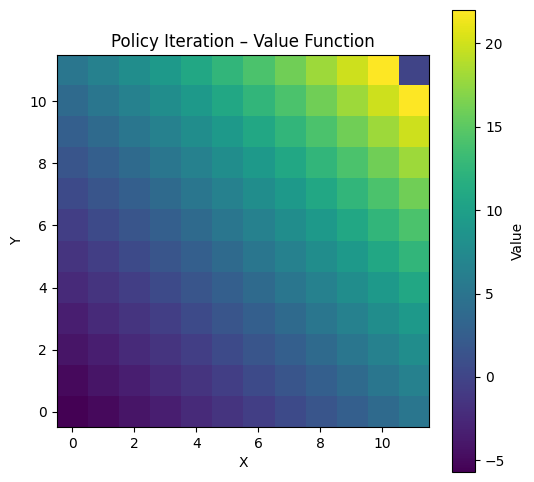

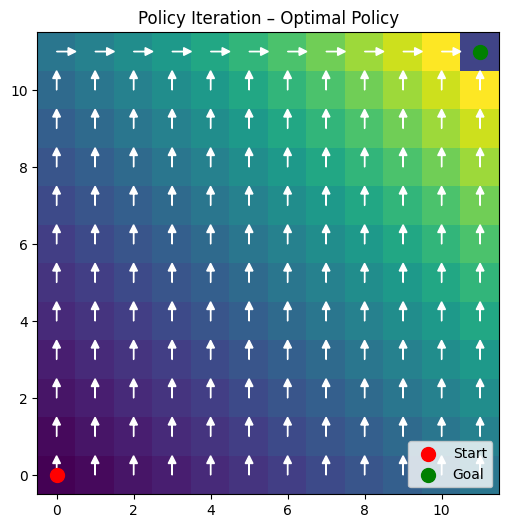

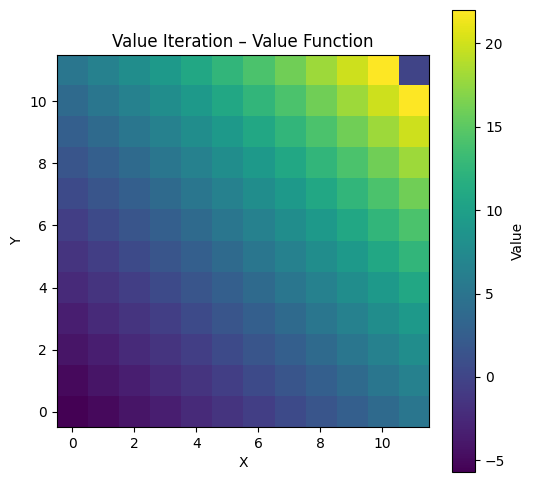

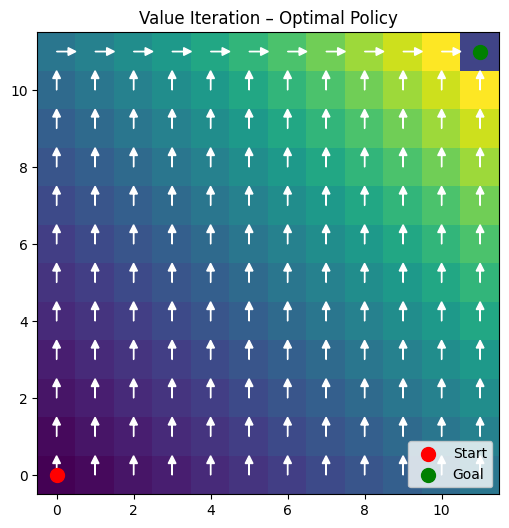

In [ ]:
plot_value_function(V_pi, "Policy Iteration – Value Function")
plot_policy(V_pi, policy_pi, "Policy Iteration – Optimal Policy")

plot_value_function(V_vi, "Value Iteration – Value Function")
plot_policy(V_vi, policy_vi, "Value Iteration – Optimal Policy")
